# Quantum Likelihood Estimation

> **Quantum Likelihood Estimation** (QLE) [\[1, 2\]](#wiebe14a), is a hybrid algorithm for Hamiltonian learning, originally proposed for efficiently learning Hamiltonians from quantum experiments. The basic setting is that the algorithm can access the true Hamiltonian only through the evolution it generates, namely the unitary $U(t)=e^{-iHt}$ for an arbitrarily chosen time $t$. Such experiments on the true physical system are considered an expensive resource, analogous to oracle queries, and the goal is to perform as few experiments as possible. QLE has also been demonstrated experimentally [\[4\]](#wang17).  Ref. [\[3\]](#qle) suggested an optimized approach based on an information-theoretic framework, minimizing the number of oracle calls by jointly optimizing all circuit parameters at each iteration. The QLE problem is defined as follows:
> - **Input:** A set of possible Hamiltonians that may govern the system.
> - **Promise:** One of the Hamiltonians is the true Hamiltonian of the system.
> - **Output:** The The true Hamiltonian.
>
> 
>
> ---
>
> **Keywords:**  Hamiltonian learning, hybrid quantum–classical algorithms, Bayesian inference.


**<div class="alert alert-success">This notebook implements the Optimal Quantum Likelihood Estimation algorithm, as proposed in Ref. [\[3\]](#qle), and was developed in collaboration with the paper authors. As a reference, we also implement a naive Quantum Likelihood Estimation.</div>**

QLE frames Hamiltonian learning as Bayesian inference: a prior ("weights") over a discrete set of candidate Hamiltonians is updated iteratively from measurement outcomes obtained after evolving the system for a chosen time $t$. Thus, a quantum iteration consists of preparation, evolution and measurement. Between each two quantum steps, there is a classical processing phase, where we update the weights and design the next quantum step based on the weights. The efficiency of each step depends critically on how informative the measurement is.

Standard QLE selects $t$ heuristically (e.g. via PGH) while keeping the state-preparation and measurement angles fixed. Ref. [[3]](#qle) proposes instead to **jointly optimize all five circuit parameters** — evolution time $t$ and angles $(\alpha, \beta, \theta, \phi)$ — at each iteration, so as to maximize the mutual information $I(F;Y)$ between the measurement outcome $Y$ and the unknown Hamiltonian $F$. The optimization is solved classically via simulated annealing. In the single-qubit benchmark of Ref. [[3]](#qle), this information-theoretic approach converges in roughly an order of magnitude fewer iterations than standard QLE.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np

from classiq import *

## Defining a Single Qubit Example

Following Ref. [\[3\]](#qle) we work with a single qubit example, which underlines the idea behind the optimal, information based optimization.

We set the quantum model for a single qubit example

The QLE circuit consists of three components. The initial state is parameterized by $\alpha \in [0, \pi]$ and $\beta \in [0, 2\pi)$:

$$|\psi_1\rangle = \cos(\alpha)\,|0\rangle + e^{i\beta}\sin(\alpha)\,|1\rangle \qquad (1)$$

*(Eq. (8) in Ref. [[3]](#qle))*

After Hamiltonian evolution $e^{-iHt}$, the measurement basis is rotated by $W$, parameterized by $\theta \in [0, \pi]$ and $\phi \in [0, 2\pi)$:

$$W = e^{-i\theta\sigma_y/2}\,e^{-i\phi\sigma_z/2} \qquad (2)$$

*(Eq. (9) in Ref. [[3]](#qle))*

In [2]:
# ranges for [alpha, beta, theta, phi]
PARAMS_RANGE = [np.pi, 2 * np.pi, np.pi, 2 * np.pi]


@qfunc
def prepare_psi1(alpha: CReal, beta: CReal, q: QBit):
    RY(2 * alpha, q)
    phase(q == 1, beta)


@qfunc
def w_func(theta: CReal, phi: CReal, q: QBit):
    U(theta, phi, np.pi - phi, 0, q)


@qfunc
def hamiltonian_evolution(h: SparsePauliOp, t: CReal, q: QBit):
    suzuki_trotter(h, t, 1, 1, q)

The full circuit maps parameters $\vec{\lambda} = (\alpha, \beta, \theta, \phi)$ and evolution time $t$ to a measurement distribution. The probability of outcome $a \in \{0, 1\}$ under hypothesis $H_j$ is:

$$p_j^{(a)}(t, \vec{\lambda}) = \bigl|\langle a \mid W\,e^{-iH_j t}\,|\psi_1\rangle\bigr|^2 \qquad (3)$$

*(Eq. (6) in Ref. [[3]](#qle))*

Since each hypothesis corresponds to a different Hamiltonian, we synthesize one parametric quantum program per hypothesis.

In [3]:
def get_main_for_hamiltonian_evolution(h: SparsePauliOp):
    @qfunc
    def main(
        t: CReal,
        params: CArray[CReal, 4],  # [alpha, beta, theta, phi]
        q: Output[QBit],
    ):
        allocate(q)
        prepare_psi1(params[0], params[1], q)
        hamiltonian_evolution(h, t, q)
        w_func(params[2], params[3], q)

    return main


def get_qprogs_for_hamiltonian_evolutions(
    h_list: list[SparsePauliOp],
) -> list[QuantumProgram]:
    """
    This function generates a list of quantum programs for a given list of Hamiltonians
    """
    print("Starting synthesis for all parametrized qprogs")
    qprogs = [synthesize(get_main_for_hamiltonian_evolution(h)) for h in h_list]
    show(qprogs[0])  # visualize one of the qprogs
    print("Finished synthesis")

    return qprogs

### Setting Up a Specific Hamiltonian Set

We define the pool of Hamiltonians and the true index for the demonstration. 

In [4]:
HAMILTONIAN_SET = [Pauli.X(0), 2 * Pauli.X(0), Pauli.Z(0), 2 * Pauli.Z(0)]
TRUE_IDX = 0  # the index of the true Hamiltonian

print("The set of possible Hamiltonians: ")
print(*HAMILTONIAN_SET, sep=", ")
print(f"The true Hamiltonian:  {HAMILTONIAN_SET[TRUE_IDX]}")

The set of possible Hamiltonians: 
Pauli.X(0), 2.0*Pauli.X(0), Pauli.Z(0), 2.0*Pauli.Z(0)
The true Hamiltonian:  Pauli.X(0)


In [5]:
qprogs = get_qprogs_for_hamiltonian_evolutions(HAMILTONIAN_SET)

Starting synthesis for all parametrized qprogs
Quantum program link: https://platform.classiq.io/circuit/3FunTTt1DD1MEBrZbavfly11Uhz
Finished synthesis


## Classical functions for maximum likelihood

The QLE is based on Bayesian inference. We start with a normalized list of weights, each assigned for the different hypothesis $H_j$:
$$
\vec{w} = (w_0, w_1,\dots, w_{M-1}), \qquad \sum^{M-1}_{j=0}w_j = 1. 
$$
Then, upon measuring outcome $y$ from the true system, the likelihood of hypothesis $H_j$ is $\mathcal{L}_j = p_j^{(y)}$. The Bayesian weight update from step $k$ to $k+1$ reads:

$$w_j^{(k+1)} = \frac{w_j^{(k)}\,p_j^{(y)}}{\displaystyle\sum_i w_i^{(k)}\,p_i^{(y)}} \qquad (4),$$
where the denominator guarantees that the weights vector stays normalized; *See (Eq. (7) in Ref. [[3]](#qle))*.


Below we define the functions `get_probs_from_qprog`, which computes $\{p_j^{(a)}\}_a$ via exact statevector simulation, and `bayes_update` that performs one step of Eq. (4).

In [6]:
def get_probs_from_qprog(qprog: QuantumProgram, t_list, params_list) -> np.ndarray:
    """
    Gets exact probabilities from a batch execution on a statevector simulator
    """
    dfs = calculate_state_vector(
        qprog,
        parameters=[
            {"t": t, "params": params} for t, params in zip(t_list, params_list)
        ],
    )
    variable_size = qprog.model.circuit_output_types[
        "q"
    ].size  # =1 as we are looking at a single qubit case
    probs = np.zeros((len(t_list), 2**variable_size), dtype=float)
    for i, df in enumerate(dfs):
        probs[i, df["q"]] = df["probability"]
    return probs


def bayes_update(
    qprogs: list[QuantumProgram], true_index: int, t, params, weights
) -> np.ndarray:
    """
    Bayesian update of the weights
    """

    # True experimental outcome from sampling the evolution of the true Hamiltonian
    print("Sample true evolution")
    df = sample(qprogs[true_index], num_shots=1, parameters={"t": t, "params": params})
    outcome = int(df["q"].item())

    # Likelihood under every hypothesis
    print("Calculate likelihood")
    likelihoods = np.zeros(len(qprogs))
    for i, qprog in enumerate(qprogs):
        probs = get_probs_from_qprog(qprog, [t], [params])[0]
        likelihoods[i] = probs[outcome]

    print("Updating weights")
    new_weights = np.asarray(weights, dtype=float) * np.asarray(
        likelihoods, dtype=float
    )
    new_weights = np.clip(new_weights, 0.0, None)
    new_weights /= sum(new_weights)
    return outcome, likelihoods, new_weights

## A Standard Quantum Likelihood

In the naive QLE algorithm, we simply follow a series of Bayesian updates, where the evolution time $t$ at each iteration can varies, and the other model parameters $\vec{\lambda}$  are fixed. Here $t$ is selected by the **Particle Guess Heuristic (PGH)**: draw two hypotheses $H_i,\,H_j$ from the current weight distribution and set

$$t = \frac{1}{\|H_i - H_j\|} \qquad (5)$$
*(See Ref. [[3]](#qle))*


In [7]:
def pgh(h_list, weights, rng=None) -> float:
    """
    PGH choice for the time evolution parameter:
    sample two hypotheses from current weights and take t = 1 / ||Hi - Hj||.
    """
    rng = np.random.default_rng() if rng is None else rng
    i, j = rng.choice(len(weights), size=2, replace=False, p=weights)
    nh = np.linalg.norm(
        hamiltonian_to_matrix(h_list[i]) - hamiltonian_to_matrix(h_list[j])
    )
    return 0.1 if nh < 1e-6 else 1.0 / nh

Next, we define the main `run_qle` function, which iterates the standard QLE loop: select $t$ via Eq. (5), sample the true Hamiltonian to obtain outcome $y$, and apply the Bayes update (Eq. (4)) until the posterior weight of one hypothesis exceeds the convergence threshold.

In [8]:
def run_qle(
    h_list,
    true_index,
    fixed_params,
    threshold: float = 0.99,
    max_iters: int = 10_000,
    rng=None,
    qprogs=None,
):
    rng = np.random.default_rng() if rng is None else rng
    weights = np.ones(len(h_list), dtype=float) / len(h_list)
    history = []

    if qprogs is None:
        qprogs = get_qprogs_for_hamiltonian_evolutions(h_list)
    for it in range(1, max_iters + 1):
        # if np.max(weights) >= threshold:
        if weights[true_index] > threshold:
            break

        t = pgh(h_list, weights, rng=rng)
        outcome, likelihoods, new_weights = bayes_update(
            qprogs, true_index, t, fixed_params, weights
        )
        history.append(
            {
                "t": t,
                "params": fixed_params,
                "outcome": outcome,
                "likelihoods": likelihoods,
                "weights_before": np.array(weights, dtype=float),
                "weights_after": new_weights,
            }
        )
        weights = new_weights

        print(f"Iteration {it+1}: weights = {new_weights}")

    return {
        "final_weights": weights,
        "num_iters": len(history),
        "history": history,
        "guess_idx": int(np.argmax(weights)),
    }

### Run for the Specific Example

In [9]:
params = [1.2566, 0.5712, 0.7854, 2 * np.pi]  # fixed parameters

In [10]:
from classiq.execution.functions.util._logging import _logger

_logger.setLevel(logging.WARNING)  # disable the logging for the loop

res_qle = run_qle(
    h_list=HAMILTONIAN_SET,
    true_index=0,
    fixed_params=params,
    threshold=0.99,
    max_iters=10_000,
    rng=np.random.default_rng(1234),
    qprogs=qprogs,
)

_logger.setLevel(logging.INFO)  # return to default after the loop

Sample true evolution
Calculate likelihood
Updating weights
Iteration 2: weights = [0.21945155 0.16182579 0.2884259  0.33029677]
Sample true evolution
Calculate likelihood
Updating weights
Iteration 3: weights = [0.18061965 0.0982162  0.31200116 0.40916299]
Sample true evolution
Calculate likelihood
Updating weights
Iteration 4: weights = [0.39412498 0.3123227  0.23684465 0.05670767]
Sample true evolution
Calculate likelihood
Updating weights
Iteration 5: weights = [0.40573844 0.43821025 0.1378154  0.01823591]
Sample true evolution
Calculate likelihood
Updating weights
Iteration 6: weights = [4.01493859e-01 5.74223064e-01 2.39658413e-02 3.17235444e-04]
Sample true evolution
Calculate likelihood
Updating weights
Iteration 7: weights = [3.44299545e-01 6.52083966e-01 3.61170613e-03 4.78256498e-06]
Sample true evolution
Calculate likelihood
Updating weights
Iteration 8: weights = [2.84910678e-01 7.14564025e-01 5.25226788e-04 6.95752525e-08]
Sample true evolution
Calculate likelihood
Updati

In [11]:
assert (
    res_qle["guess_idx"] == TRUE_IDX
), f"QLE converged to hypothesis {res_qle['guess_idx']} but expected {TRUE_IDX}"
assert (
    res_qle["final_weights"][TRUE_IDX] >= 0.99
), f"QLE weight for true hypothesis is {res_qle['final_weights'][TRUE_IDX]:.4f}, expected >= 0.99"
print(
    f"QLE passed: converged to correct hypothesis {TRUE_IDX} in {res_qle['num_iters']} iterations"
)

QLE passed: converged to correct hypothesis 0 in 16 iterations


### Plotting the convergence history

In [12]:
weights_history = np.array([h["weights_after"] for h in res_qle["history"]]).T

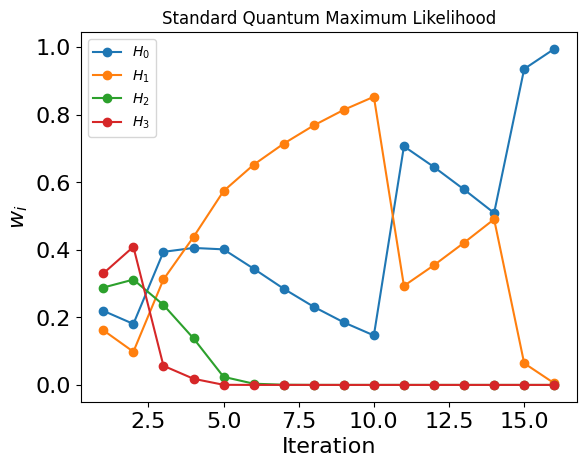

In [13]:
for i in range(4):
    plt.plot(np.arange(1, len(weights_history[i]) + 1), weights_history[i], "o-")
plt.title("Standard Quantum Maximum Likelihood")
plt.xlabel("Iteration", fontsize=16)
plt.ylabel(r"$w_i$", fontsize=16)
plt.tick_params("both", labelsize=16)
plt.legend([rf"$H_{l}$" for l in range(len(HAMILTONIAN_SET))])

## An Optimized Quantum Likelihood

Next, we follow the procedure introduced in Ref. [\[3\]](#qle). We find the optimal parameters that maximizes the mutual information, and use simulated annealing for finding them.

The optimized QLE selects $(t, \vec{\lambda})$ by minimizing the conditional Shannon entropy $H(F|Y)$ over the current posterior $\{w_j\}$:

$$H(F|Y) = \sum_y p(y)\,H(F \mid Y{=}y), \qquad p(y) = \sum_j w_j\,p_j^{(y)} \qquad (6)$$

*(Eq. (10) in Ref. [[3]](#qle))*

Minimizing $H(F|Y)$ is equivalent to maximizing the mutual information $I(F;Y)$ between the true Hamiltonian $F$ and the measurement outcome $Y$.

Below, we define `conditional_entropy_cost_batch` that calculates the cost function for a batch of parameters.

In [14]:
EPS = 1e-12  # for avoiding division by zero or log of zero


def shannon_entropy(p: np.ndarray) -> float:
    p = np.asarray(p, dtype=float)
    p = p[p > EPS]
    if p.size == 0:
        return 0.0
    return float(-np.sum(p * np.log2(p)))


def conditional_entropy_cost_batch(
    weights: list,
    qprogs_list: list[QuantumProgram],
    t_list: list[float],
    params_list: list[list[float]],
) -> np.ndarray:

    weights = np.asarray(weights, dtype=float)
    batch_size = len(t_list)

    # cond_probs[f, b, y] = p(y | f, params_b)
    cond_probs = np.array(
        [get_probs_from_qprog(qprog, t_list, params_list) for qprog in qprogs_list],
        dtype=float,
    )  # shape (N, B, 2^problem_size)

    # py[b, y] = sum_f w_f p(y|f,b)
    py = np.tensordot(weights, cond_probs, axes=(0, 0))  # shape (B, 2^problem_size)

    costs = np.zeros(batch_size, dtype=float)

    for y in range(cond_probs.shape[2]):
        py_y = py[:, y]
        valid = py_y > EPS
        if not np.any(valid):
            continue

        posterior_y = (weights.reshape(-1, 1) * cond_probs[:, :, y]) / py_y.reshape(
            1, -1
        )
        entropies = np.zeros(batch_size, dtype=float)
        for b in np.where(valid)[0]:
            entropies[b] = shannon_entropy(posterior_y[:, b])

        costs += py_y * entropies

    return costs

We also define two utility functions for wrapping the parameters values in a periodic range (since we consider angles here),
and the simulated annealing optimizer `optimize_entropy_sa`.

In [15]:
def min_energy_gap_from_paulis(h_list) -> float:
    gaps = []
    for h in h_list:
        hm = hamiltonian_to_matrix(h)
        evals = np.linalg.eigvalsh(hm)
        evals = np.sort(np.real_if_close(evals))
        diffs = np.diff(evals)
        diffs = diffs[diffs > EPS]
        if diffs.size > 0:
            gaps.append(float(np.min(diffs)))
    return min(gaps) if gaps else 1.0


def wrap_params(x: np.ndarray, ranges: list) -> np.ndarray:
    return np.array(
        [np.mod(x[i], ranges[i]) for i in range(len(ranges))],
        dtype=float,
    )

In [16]:
def optimize_entropy_sa(
    weights,
    h_list,
    qprogs_list,
    n_steps: int = 200,
    n_neighbors: int = 20,
    cooling: float = 0.90,
    seed=None,
):
    rng = np.random.default_rng(seed)
    delta_min = min_energy_gap_from_paulis(h_list)
    t_max = 2 * np.pi / delta_min
    # ranges for [t, alpha, beta, theta, phi]
    ranges = np.array([t_max] + PARAMS_RANGE, dtype=float)
    params_len = len(ranges)

    x = wrap_params(rng.random(params_len) * ranges, ranges)
    current = x.copy()
    current_cost = conditional_entropy_cost_batch(
        weights, qprogs_list, [current[0]], [current[1:].tolist()]
    )[0]

    best = current.copy()
    best_cost = current_cost
    T = 1.0

    for step_idx in range(n_steps):
        print(f"SA step {step_idx+1}/{n_steps}")

        neighbors = current + T * (
            rng.uniform(-1, 1, size=(n_neighbors, params_len)) * (ranges / 2.0)
        )
        neighbors = np.array([wrap_params(z, ranges) for z in neighbors])

        t_batch = neighbors[:, 0].tolist()
        params_batch = [z[1:].tolist() for z in neighbors]
        neighbor_costs = conditional_entropy_cost_batch(
            weights, qprogs_list, t_batch, params_batch
        )

        best_idx = int(np.argmin(neighbor_costs))
        candidate = neighbors[best_idx]
        candidate_cost = float(neighbor_costs[best_idx])

        if candidate_cost < current_cost:
            accept = True
        else:
            prob = np.exp((current_cost - candidate_cost) / max(T, 1e-15))
            accept = rng.random() < prob

        if accept:
            current = candidate
            current_cost = candidate_cost

        if current_cost < best_cost:
            best = current.copy()
            best_cost = current_cost

        T *= cooling

    return best[0], best[1:].tolist(), best_cost

Finally we define the main `run_optimized_qle` function, that runs over the optimized QLE steps. Compared to the standard QLE (`run_qle`), we replace the PGH with the simulated annealing optimizer: at each iteration the optimal $(t, \vec{\lambda})$ minimizing $H(F|Y)$ is found, the true system is sampled, and the Bayes update (Eq. (4)) is applied.

In [17]:
def run_optimized_qle(
    h_list,
    true_index,
    threshold: float = 0.99,
    max_iters: int = 100,
    rng=None,
    optimizer_kwargs=None,
    qprogs=None,
):
    rng = np.random.default_rng() if rng is None else rng
    optimizer_kwargs = {} if optimizer_kwargs is None else dict(optimizer_kwargs)

    weights = np.ones(len(h_list), dtype=float) / len(h_list)
    history = []

    qprogs_list = (
        get_qprogs_for_hamiltonian_evolutions(h_list) if qprogs is None else qprogs
    )

    for it in range(max_iters):
        # if np.max(weights) >= threshold:
        if weights[true_index] > threshold:
            break
        t, params, cost = optimize_entropy_sa(
            weights=weights,
            h_list=h_list,
            qprogs_list=qprogs_list,
            **optimizer_kwargs,
        )

        outcome, likelihoods, new_weights = bayes_update(
            qprogs_list, true_index, t, params, weights
        )
        history.append(
            {
                "t": t,
                "params": params,
                "outcome": outcome,
                "likelihoods": likelihoods,
                "weights_before": np.array(weights, dtype=float),
                "weights_after": new_weights,
            }
        )
        weights = new_weights

        print(f"Iteration {it+1}: weights = {new_weights}")

    return {
        "final_weights": weights,
        "num_iters": len(history),
        "history": history,
        "guess_idx": int(np.argmax(weights)),
    }

### Run for the Specific Example

In [18]:
_logger.setLevel(logging.WARNING)  # disable the logging for the loop

res_oqle = run_optimized_qle(
    h_list=HAMILTONIAN_SET,
    true_index=0,
    threshold=0.99,
    max_iters=100,
    rng=np.random.default_rng(1234),
    optimizer_kwargs={
        "n_steps": 8,
        "n_neighbors": 20,
        "cooling": 0.9,
        "seed": 1234,
    },
    qprogs=qprogs,
)

_logger.setLevel(logging.INFO)  # return to default after the loop

SA step 1/8
SA step 2/8
SA step 3/8
SA step 4/8
SA step 5/8
SA step 6/8
SA step 7/8
SA step 8/8
Sample true evolution
Calculate likelihood
Updating weights
Iteration 1: weights = [0.37433638 0.62130421 0.00233752 0.0020219 ]
SA step 1/8
SA step 2/8
SA step 3/8
SA step 4/8
SA step 5/8
SA step 6/8
SA step 7/8
SA step 8/8
Sample true evolution
Calculate likelihood
Updating weights
Iteration 2: weights = [9.67488265e-01 3.22181561e-02 1.58664735e-04 1.34913783e-04]
SA step 1/8
SA step 2/8
SA step 3/8
SA step 4/8
SA step 5/8
SA step 6/8
SA step 7/8
SA step 8/8
Sample true evolution
Calculate likelihood
Updating weights
Iteration 3: weights = [9.99611193e-01 3.80579579e-04 1.53544567e-06 6.69148865e-06]


In [19]:
assert (
    res_oqle["guess_idx"] == TRUE_IDX
), f"Optimized QLE converged to hypothesis {res_oqle['guess_idx']} but expected {TRUE_IDX}"
assert (
    res_oqle["final_weights"][TRUE_IDX] >= 0.99
), f"Optimized QLE weight for true hypothesis is {res_oqle['final_weights'][TRUE_IDX]:.4f}, expected >= 0.99"
print(
    f"Optimized QLE passed: converged to correct hypothesis {TRUE_IDX} in {res_oqle['num_iters']} iterations"
)

Optimized QLE passed: converged to correct hypothesis 0 in 3 iterations


### Plotting the convergence history

In [20]:
weights_history = np.array([h["weights_after"] for h in res_oqle["history"]]).T

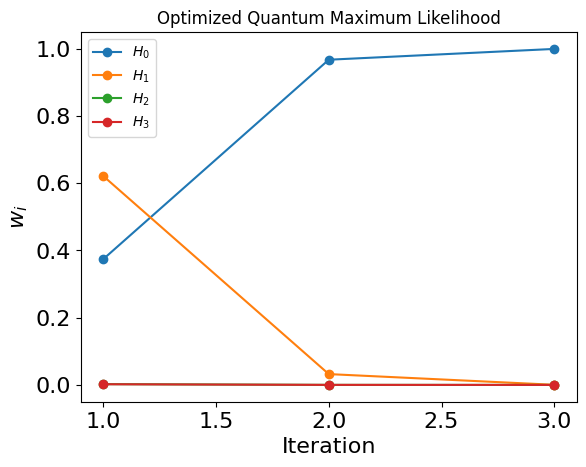

In [21]:
for i in range(4):
    plt.plot(np.arange(1, len(weights_history[i]) + 1), weights_history[i], "o-")

plt.title("Optimized Quantum Maximum Likelihood")
plt.xlabel("Iteration", fontsize=16)
plt.ylabel(r"$w_i$", fontsize=16)
plt.tick_params("both", labelsize=16)
plt.legend([rf"$H_{l}$" for l in range(len(HAMILTONIAN_SET))])

## Summary

In this notebook we implemented two versions of the Quantum Likelihood Estimation algorithm: the standard version, and a version that utilizes information-based optimization. We demonstrated that information-based optimization yields faster convergence, compared to the standard version.

## References
<a id='wiebe14a'>[1]</a>: Wiebe N, Granade C, Ferrie C and Cory D G 2014 Hamiltonian learning using imperfect quantum resources *Phys. Rev. A* **89** 042314

<a id='wiebe14b'>[2]</a>: Wiebe N, Granade C, Ferrie C and Cory D G 2014 Hamiltonian learning and certification using quantum resources *Phys. Rev. Lett.* **112** 190501

<a id='qle'>[3]</a>: [Levi, Alon and Ossi, Ziv and Cohen, Eliahu and Te'eni, Amit. Optimal quantum likelihood estimation. Quantum Science and Technology 11 015029 (2025)](https://doi.org/10.1088/2058-9565/ae2b31)

<a id='wang17'>[4]</a>: Wang J *et al* 2017 Experimental quantum Hamiltonian learning *Nat. Phys.* **13** 551–555